In [22]:
import pandas as pd

df_hok = pd.read_csv('hok_reviews_clean.csv')
df_mlbb = pd.read_csv('mlbb_reviews_clean.csv')

# 1-gram


In [23]:
from sklearn.feature_extraction.text import CountVectorizer

def generate_ngrams_for_review(text_list, n):
    # Ensure text_list is a list and contains strings
    text_strings = [" ".join(text) for text in text_list if text] # Filter out empty lists
    if not text_strings: # Handle cases where all texts are empty after filtering
        return []

    vectorizer = CountVectorizer(ngram_range=(n, n))
    try:
        X = vectorizer.fit_transform(text_strings)
        feature_names = vectorizer.get_feature_names_out()
        # Return a list of n-grams for this specific review
        return list(feature_names)
    except ValueError:
        # Handle cases where the vocabulary is still empty after vectorization
        return []


# Apply the function to generate 1-grams for each review
df_hok['1-gram'] = df_hok['stopwords_removed'].apply(lambda x: generate_ngrams_for_review([eval(x)], 1))
df_mlbb['1-gram'] = df_mlbb['stopwords_removed'].apply(lambda x: generate_ngrams_for_review([eval(x)], 1))

In [24]:
# Select the specified columns from df_hok and save to CSV
df_hok[['stopwords_removed', '1-gram']].to_csv('hok_1gram_results.csv', index=False)

# Select the specified columns from df_mlbb and save to CSV
df_mlbb[['stopwords_removed', '1-gram']].to_csv('mlbb_1gram_results.csv', index=False)

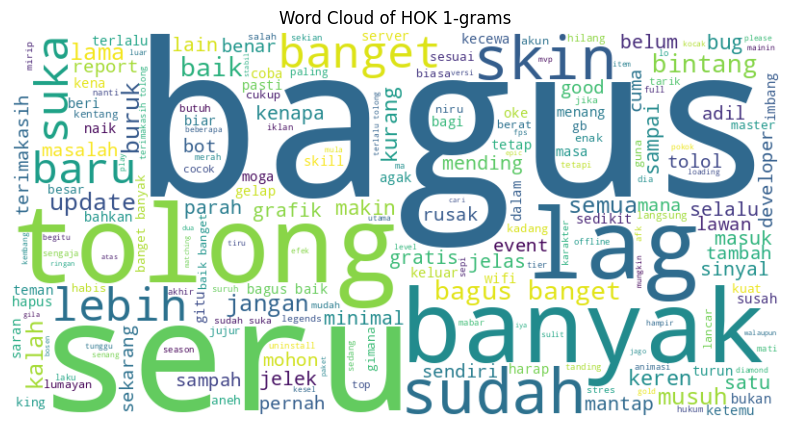

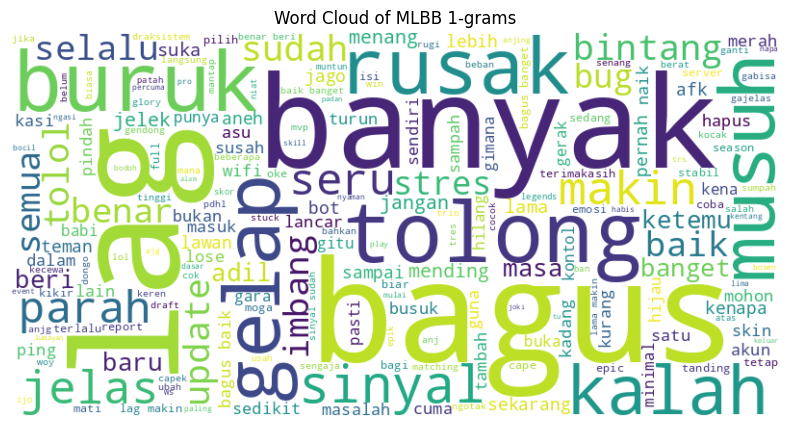

In [25]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all HOK 1-grams into a single string
hok_1grams_combined = ' '.join([' '.join(gram_list) for gram_list in df_hok['1-gram'] if gram_list])

# Create and generate a word cloud image for HOK
hok_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(hok_1grams_combined)

# Display the HOK word cloud
plt.figure(figsize=(10, 5))
plt.imshow(hok_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of HOK 1-grams')
plt.show()

# Combine all MLBB 1-grams into a single string
mlbb_1grams_combined = ' '.join([' '.join(gram_list) for gram_list in df_mlbb['1-gram'] if gram_list])

# Create and generate a word cloud image for MLBB
mlbb_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(mlbb_1grams_combined)

# Display the MLBB word cloud
plt.figure(figsize=(10, 5))
plt.imshow(mlbb_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of MLBB 1-grams')
plt.show()

# 2-gram



In [26]:
from sklearn.feature_extraction.text import CountVectorizer

def generate_ngrams_for_review(text_list, n):
    """Generates n-grams from a list of text tokens."""
    text_strings = [" ".join(text) for text in text_list if text]
    if not text_strings:
        return []

    vectorizer = CountVectorizer(ngram_range=(n, n))
    try:
        X = vectorizer.fit_transform(text_strings)
        feature_names = vectorizer.get_feature_names_out()
        # Join n-grams with an underscore if n > 1
        if n > 1:
            feature_names = ["_".join(name.split()) for name in feature_names]
        return list(feature_names)
    except ValueError:
        return []

# Apply the function to generate 2-grams for each review in df_hok
df_hok['2-gram'] = df_hok['stopwords_removed'].apply(lambda x: generate_ngrams_for_review([eval(x)], 2))

# Apply the function to generate 2-grams for each review in df_mlbb
df_mlbb['2-gram'] = df_mlbb['stopwords_removed'].apply(lambda x: generate_ngrams_for_review([eval(x)], 2))

In [27]:
# Select the specified columns from df_hok and save to CSV
df_hok[['stopwords_removed', '2-gram']].to_csv('hok_2gram_results.csv', index=False)

# Select the specified columns from df_mlbb and save to CSV
df_mlbb[['stopwords_removed', '2-gram']].to_csv('mlbb_2gram_results.csv', index=False)

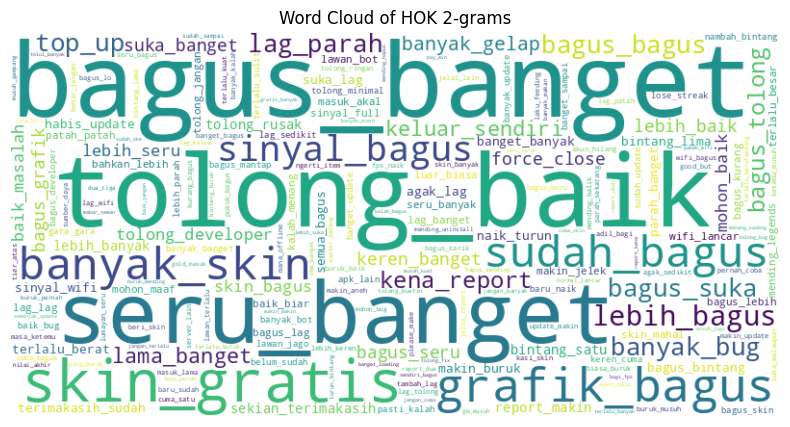

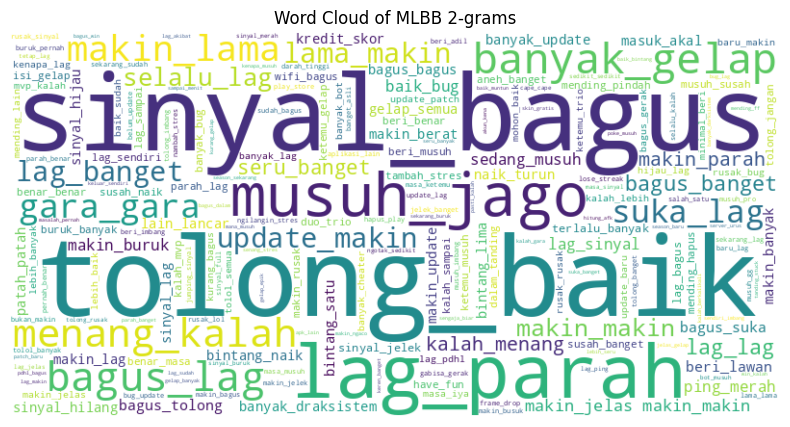

In [28]:
# Combine all HOK 2-grams into a single string
hok_2grams_combined = ' '.join([' '.join(gram_list) for gram_list in df_hok['2-gram'] if gram_list])

# Create and generate a word cloud image for HOK 2-grams
hok_wordcloud_2gram = WordCloud(width=800, height=400, background_color='white').generate(hok_2grams_combined)

# Display the HOK 2-gram word cloud
plt.figure(figsize=(10, 5))
plt.imshow(hok_wordcloud_2gram, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of HOK 2-grams')
plt.show()

# Combine all MLBB 2-grams into a single string
mlbb_2grams_combined = ' '.join([' '.join(gram_list) for gram_list in df_mlbb['2-gram'] if gram_list])

# Create and generate a word cloud image for MLBB 2-grams
mlbb_wordcloud_2gram = WordCloud(width=800, height=400, background_color='white').generate(mlbb_2grams_combined)

# Display the MLBB 2-gram word cloud
plt.figure(figsize=(10, 5))
plt.imshow(mlbb_wordcloud_2gram, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of MLBB 2-grams')
plt.show()

# 3-gram

In [29]:
# Apply the function to generate 3-grams for each review in df_hok
df_hok['3-gram'] = df_hok['stopwords_removed'].apply(lambda x: generate_ngrams_for_review([eval(x)], 3))

# Apply the function to generate 3-grams for each review in df_mlbb
df_mlbb['3-gram'] = df_mlbb['stopwords_removed'].apply(lambda x: generate_ngrams_for_review([eval(x)], 3))

In [30]:
# Select the specified columns from df_hok and save to CSV
df_hok[['stopwords_removed', '3-gram']].to_csv('hok_3gram_results.csv', index=False)

# Select the specified columns from df_mlbb and save to CSV
df_mlbb[['stopwords_removed', '3-gram']].to_csv('mlbb_3gram_results.csv', index=False)

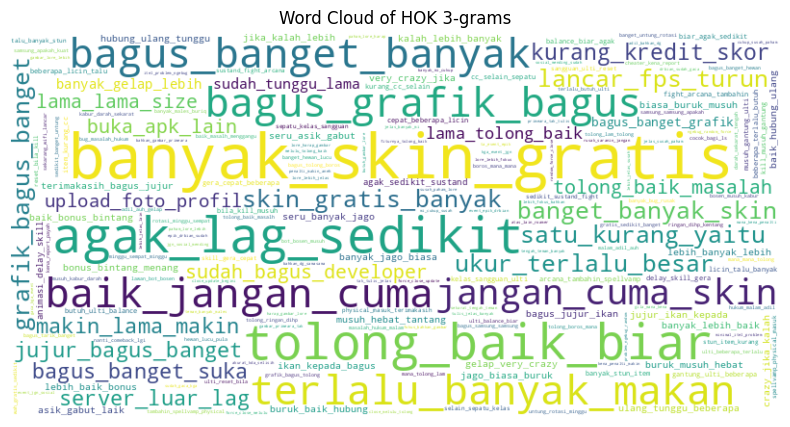

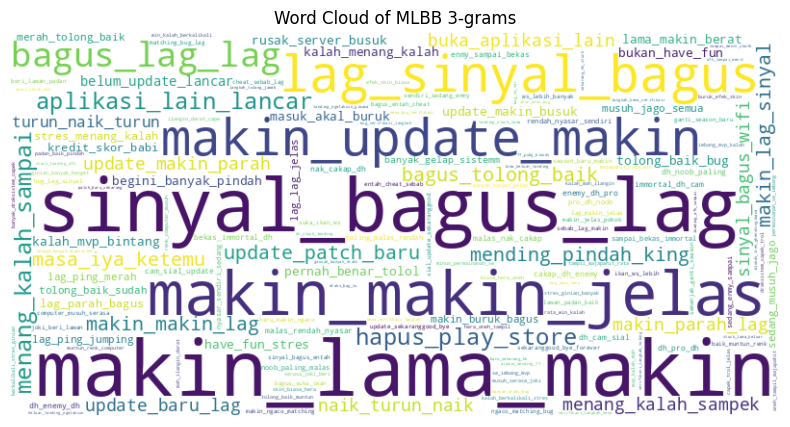

In [31]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all HOK 3-grams into a single string
hok_3grams_combined = ' '.join([' '.join(gram_list) for gram_list in df_hok['3-gram'] if gram_list])

# Create and generate a word cloud image for HOK 3-grams
hok_wordcloud_3gram = WordCloud(width=800, height=400, background_color='white').generate(hok_3grams_combined)

# Display the HOK 3-gram word cloud
plt.figure(figsize=(10, 5))
plt.imshow(hok_wordcloud_3gram, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of HOK 3-grams')
plt.show()

# Combine all MLBB 3-grams into a single string
mlbb_3grams_combined = ' '.join([' '.join(gram_list) for gram_list in df_mlbb['3-gram'] if gram_list])

# Create and generate a word cloud image for MLBB 3-grams
mlbb_wordcloud_3gram = WordCloud(width=800, height=400, background_color='white').generate(mlbb_3grams_combined)

# Display the MLBB 3-gram word cloud
plt.figure(figsize=(10, 5))
plt.imshow(mlbb_wordcloud_3gram, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of MLBB 3-grams')
plt.show()